# Requirement Setup

In [1]:
!pip install prophet
!pip install scikit-learn
!pip install tensorflow
!pip install setuptools

In [2]:
%pip install keras-tuner

import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt
import numpy as np
import time
import matplotlib.pyplot as plt
from datetime import datetime
from prophet.serialize import model_to_json, model_from_json

Note: you may need to restart the kernel to use updated packages.


Importing plotly failed. Interactive plots will not work.


Enable / Disable Hyperparameter Tuning

In [3]:
HYPERPARAMETER_TUNING = False

In [4]:
np.random.seed(42)
tf.random.set_seed(42)

# Data Loading

In [5]:
raw_df = pd.read_csv('data.csv', parse_dates=['timestamp'])
primary_service = raw_df['service_id'].mode()[0]
df_pods = raw_df[raw_df['service_id'] == primary_service].copy()
df_pods = df_pods.sort_values('timestamp').drop_duplicates(subset='timestamp')
df_pods.rename(columns={'timestamp': 'ds', 'current_pod_count': 'pod_count'}, inplace=True)
feature_cols = [c for c in df_pods.columns if c not in ['ds', 'service_id', 'pod_count']]

print(f'Using service: {primary_service}')
print(f'Dataset length: {len(df_pods)} | Feature count: {len(feature_cols)}')
df_pods[['ds', 'pod_count']].head()

Using service: Order
Dataset length: 43200 | Feature count: 20


,ds,pod_count
0,2025-11-01 00:00:00,2
1,2025-11-01 00:01:00,2
2,2025-11-01 00:02:00,2
3,2025-11-01 00:03:00,2
4,2025-11-01 00:04:00,2


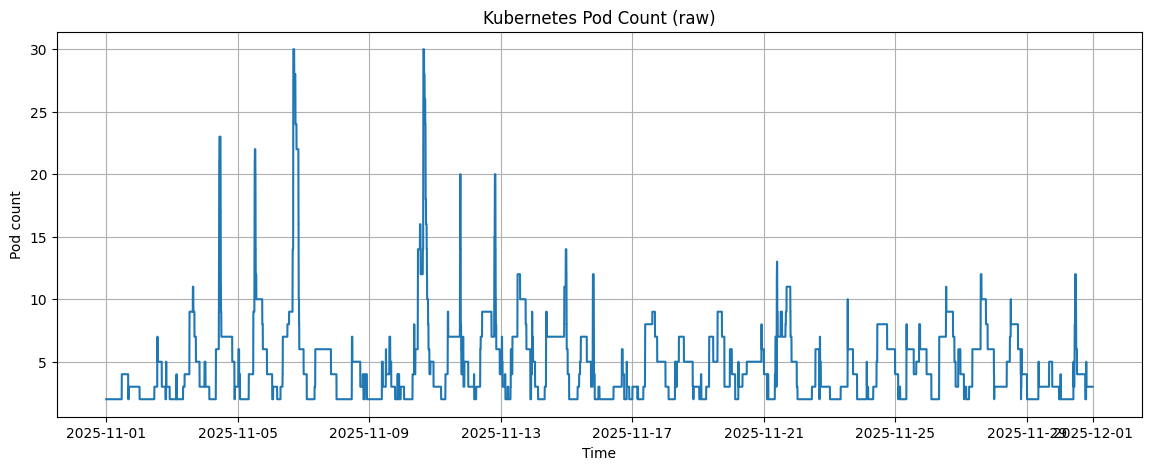

In [6]:
import os

# ensure images directory exists before saving plots
os.makedirs("images", exist_ok=True)

plt.figure(figsize=(14, 5))
plt.plot(df_pods['ds'], df_pods['pod_count'])
plt.title('Kubernetes Pod Count (raw)')
plt.xlabel('Time')
plt.ylabel('Pod count')
plt.grid(True)
plt.savefig("images/pods-raw.jpeg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

# Data Splitting & Preprocessing

1. Scale pod count and features to 0-1
2. Split dataset as 70% training, 30% testing (time-ordered)
3. Forward-fill missing values
4. Drop duplicate timestamps

In [7]:
target_scaler = MinMaxScaler(feature_range=(0, 1))
feature_scaler = MinMaxScaler()

df_pods['y'] = target_scaler.fit_transform(df_pods[['pod_count']])
df_pods[feature_cols] = feature_scaler.fit_transform(df_pods[feature_cols])

In [8]:
train_df_pods, test_df_pods = train_test_split(df_pods, test_size=0.3, random_state=42, shuffle=False)

print(f'POD DATASET: Train Set: {train_df_pods.shape} | Test Set: {test_df_pods.shape}')

POD DATASET: Train Set: (30240, 24) | Test Set: (12960, 24)


In [9]:
train_df_pods['y'].fillna(method='ffill', inplace=True)
train_df_pods.drop_duplicates(subset='ds', inplace=True)

print(f'POD DATASET: Train Set: {train_df_pods.shape} | Test Set: {test_df_pods.shape}')

POD DATASET: Train Set: (30240, 24) | Test Set: (12960, 24)


C:\Users\dilee\AppData\Local\Temp\ipykernel_20140\4286280144.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df_pods['y'].fillna(method='ffill', inplace=True)
C:\Users\dilee\AppData\Local\Temp\ipykernel_20140\4286280144.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train_df_pods['y'].fillna(method='ffill', inplace=True)


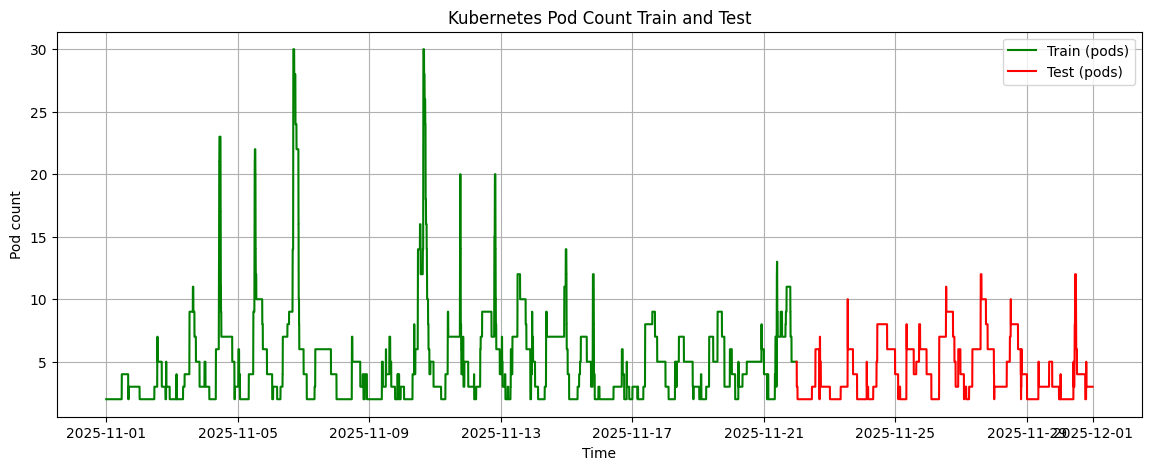

In [10]:
plt.figure(figsize=(14, 5))
plt.plot(train_df_pods['ds'], train_df_pods['pod_count'], label='Train (pods)', color='green')
plt.plot(test_df_pods['ds'], test_df_pods['pod_count'], label='Test (pods)', color='red')
plt.title('Kubernetes Pod Count Train and Test')
plt.xlabel('Time')
plt.ylabel('Pod count')
plt.grid(True)
plt.legend()
plt.savefig("images/pods-train-test.jpeg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

# Model Training

## Seasonality Capturing with Prophet

### Train Model

In [11]:
model_one = Prophet(
    growth='flat',
    changepoint_prior_scale=5.1,
    yearly_seasonality=False,
    weekly_seasonality=20,
    daily_seasonality=50,
    seasonality_prior_scale=30
)
model_one.fit(train_df_pods[['ds', 'y']])

17:45:19 - cmdstanpy - INFO - Chain [1] start processing
17:45:24 - cmdstanpy - INFO - Chain [1] done processing


### Predict Dataset

In [12]:
# Use chunked prediction to avoid creating a huge design matrix in memory
def chunked_predict(model, df, chunk_size=5000):
    preds = []
    for i in range(0, len(df), chunk_size):
        chunk = df.iloc[i:i+chunk_size][['ds']].copy()
        preds.append(model.predict(chunk))
    return pd.concat(preds, ignore_index=True)

forecast_train_df_pods = chunked_predict(model_one, train_df_pods, chunk_size=5000)

start_time = time.time()
forecast_test_df_pods = chunked_predict(model_one, test_df_pods, chunk_size=5000)
end_time = time.time()

In [13]:
forecast_test_df_pods_analysis = test_df_pods[['ds', 'y', 'pod_count']].copy()
forecast_test_df_pods_analysis = forecast_test_df_pods_analysis.merge(forecast_test_df_pods[['ds', 'yhat']], on='ds', how='left')
forecast_test_df_pods_analysis['yhat_pods'] = target_scaler.inverse_transform(forecast_test_df_pods_analysis[['yhat']])
forecast_test_df_pods_analysis['y_true_pods'] = forecast_test_df_pods_analysis['pod_count'].values

mse = mean_squared_error(forecast_test_df_pods_analysis['y_true_pods'], forecast_test_df_pods_analysis['yhat_pods'])
rmse = np.sqrt(mse)
mae = mean_absolute_error(forecast_test_df_pods_analysis['y_true_pods'], forecast_test_df_pods_analysis['yhat_pods'])
r2 = r2_score(forecast_test_df_pods_analysis['y_true_pods'], forecast_test_df_pods_analysis['yhat_pods'])
model_one_time = (end_time - start_time) * 1000

print('=== Prophet Baseline (Pod Count) Metrics ===')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'MAE: {mae}')
print(f'R²: {r2}')
print(f'Prediction Time: {model_one_time}ms')

=== Prophet Baseline (Pod Count) Metrics ===
MSE: 2.2909108876472315
RMSE: 1.5135755308696133
MAE: 1.0672554238204264
R²: 0.5456932761629767
Prediction Time: 1348.7846851348877ms


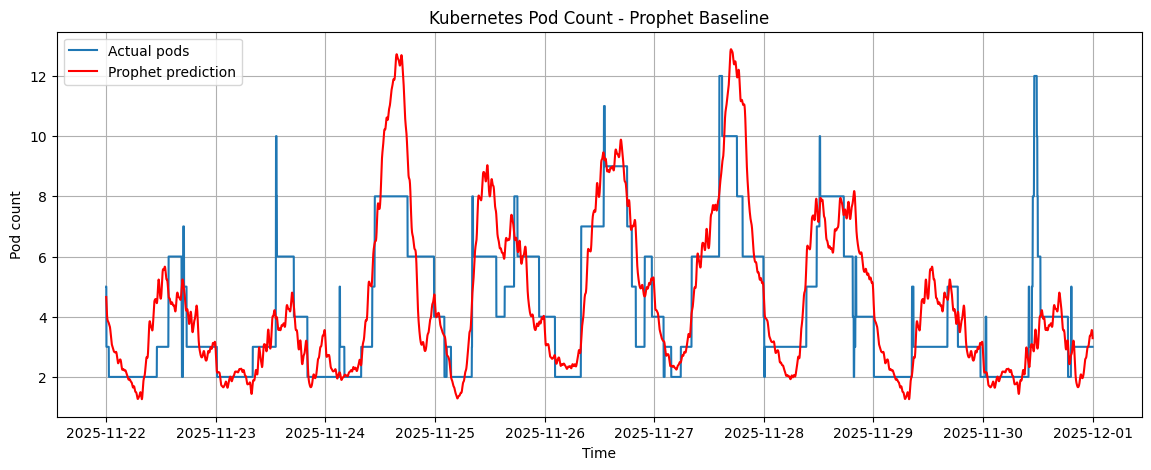

In [14]:
plt.figure(figsize=(14, 5))
plt.plot(test_df_pods['ds'], test_df_pods['pod_count'], label='Actual pods', color='#1f77b4')
plt.plot(forecast_test_df_pods['ds'], target_scaler.inverse_transform(forecast_test_df_pods[['yhat']]), label='Prophet prediction', color='red')
plt.title('Kubernetes Pod Count - Prophet Baseline')
plt.xlabel('Time')
plt.ylabel('Pod count')
plt.grid(True)
plt.legend()
plt.savefig("images/pods-prophet-output.jpeg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

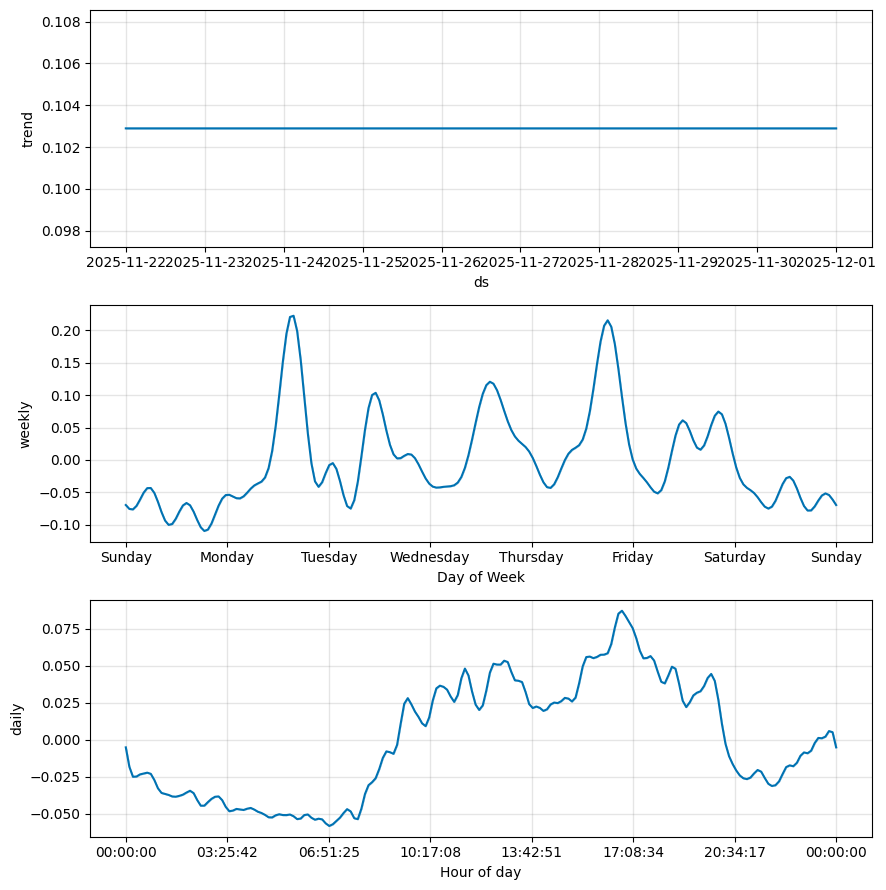

In [15]:
components_fig = model_one.plot_components(forecast_test_df_pods);
ax_weekly = components_fig.get_axes()[1]
ax_daily = components_fig.get_axes()[2]

plt.figure(figsize=(14, 5))
plt.plot(ax_weekly.lines[0].get_xdata(), ax_weekly.lines[0].get_ydata())
plt.title('Weekly Seasonality Component')
plt.xlabel(ax_weekly.get_xlabel())
plt.ylabel(ax_weekly.get_ylabel())
plt.grid(True)
plt.savefig("images/pods-prophet-weekly.jpeg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.close()

plt.figure(figsize=(14, 5))
plt.plot(ax_daily.lines[0].get_xdata(), ax_daily.lines[0].get_ydata())
plt.title('Daily Seasonality Component')
plt.xlabel(ax_daily.get_xlabel())
plt.ylabel(ax_daily.get_ylabel())
plt.grid(True)
plt.savefig("images/pods-prophet-daily.jpeg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.close()

## Merge Forecasted Data

In [16]:
forecast_df_pods = pd.concat([forecast_train_df_pods, forecast_test_df_pods])

## Residual Analysis

### Calculate Residuals

In [17]:
df_pods_residual = df_pods.merge(forecast_df_pods[['ds', 'yhat']], on='ds', how='left')
df_pods_residual['residual'] = df_pods_residual['y'] - df_pods_residual['yhat']
residual_feature_cols = feature_cols + ['residual']
df_pods_residual.head()

,ds,service_id,pod_count,request_rate_rps,latency_p95_ms,latency_p99_ms,error_rate_percent,queue_length,pod_cpu_usage_percent_avg,pod_cpu_usage_percent_p95,...,mesh_inbound_rps,mesh_inbound_latency_p95,mesh_inbound_error_rate,degree_centrality,eigenvector_centrality,betweenness_centrality,closeness_centrality,y,yhat,residual
0,2025-11-01 00:00:00,Order,2,0.025669,0.132548,0.132659,0.002166,0.0,0.216622,0.194273,...,0.024894,0.140319,0.004167,0.519777,0.343272,0.498200,0.623649,0.0,0.094849,-0.094849
1,2025-11-01 00:01:00,Order,2,0.026770,0.160436,0.177371,0.002216,0.0,0.255984,0.232739,...,0.026105,0.158184,0.002661,0.360168,0.467365,0.603060,0.533013,0.0,0.092530,-0.092530
2,2025-11-01 00:02:00,Order,2,0.028424,0.151352,0.160443,0.002314,0.0,0.251463,0.246894,...,0.028141,0.144103,0.002761,0.415077,0.618856,0.395590,0.464586,0.0,0.090183,-0.090183
3,2025-11-01 00:03:00,Order,2,0.029590,0.131849,0.112843,0.002363,0.0,0.307713,0.288925,...,0.029238,0.137490,0.005472,0.298278,0.578566,0.545005,0.663866,0.0,0.087842,-0.087842
4,2025-11-01 00:04:00,Order,2,0.029548,0.116603,0.103859,0.002363,0.0,0.273537,0.247650,...,0.028339,0.122816,0.004518,0.449977,0.471394,0.527453,0.442977,0.0,0.085537,-0.085537


### Prepare Dataset for LSTM

In [18]:
def create_dataset(features, target, look_back):
    X, y = [], []
    features = np.array(features)
    target = np.array(target)
    for i in range(len(target) - look_back):
        X.append(features[i:i + look_back, :])
        y.append(target[i + look_back])
    return np.array(X), np.array(y)

In [19]:
look_back = 1
X_pods, y_pods = create_dataset(df_pods_residual[residual_feature_cols], df_pods_residual['residual'], look_back)

In [20]:
X_train_pods, X_test_pods, y_train_pods, y_test_pods = train_test_split(X_pods, y_pods, test_size=0.3, random_state=42, shuffle=False)

num_features = X_train_pods.shape[2]

print(f'POD DATASET: Train Set: {X_train_pods.shape} | Test Set: {X_test_pods.shape}')

POD DATASET: Train Set: (30239, 1, 21) | Test Set: (12960, 1, 21)


### Model Definition

In [21]:
model_two = None

#### Early Stopping

In [22]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

#### HyperParameter Tuning (If Enabled)

In [23]:
def build_model(hp):
    model = Sequential()
    model.add(LSTM(units=hp.Int('units', min_value=32, max_value=512, step=32), return_sequences=True, input_shape=(look_back, num_features)))
    model.add(LSTM(units=hp.Int('units', min_value=32, max_value=512, step=32), return_sequences=False))
    model.add(Dense(1))
    
    model.compile(optimizer=hp.Choice('optimizer', values=['adam', 'rmsprop']), loss='mean_squared_error')
    return model

In [24]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=10,
    executions_per_trial=2,
    directory='hyperparam_tuning',
    project_name='lstm_hyperparam_tuning'
)

c:\Users\dilee\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [25]:
if HYPERPARAMETER_TUNING:
    tuner.search(X_train_fifa, y_train_fifa, epochs=50, batch_size=16, validation_split=0.2, callbacks=[early_stopping], verbose=1)

In [26]:
if HYPERPARAMETER_TUNING:
    model_two = tuner.get_best_models(num_models=1)[0]
    model_two_hyperparameters = tuner.get_best_hyperparameters(num_trials=1)[0]
    print(f"Units: {model_two_hyperparameters.get('units')}")
    print(f"Optimizer: {model_two_hyperparameters.get('optimizer')}")

#### Default Model

In [27]:
if not HYPERPARAMETER_TUNING:
    model_two = Sequential()
    model_two.add(LSTM(50, return_sequences=True, input_shape=(look_back, num_features)))
    model_two.add(LSTM(50, return_sequences=False))
    model_two.add(Dense(1))
    model_two.compile(optimizer='adam', loss='mean_squared_error')

Print Model Summery

In [28]:
model_two.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 1, 50)          │        14,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,651 (135.36 KB)

 Trainable params: 34,651 (135.36 KB)

 Non-trainable params: 0 (0.00 B)

### Train Model

In [29]:
model_two.fit(X_train_pods, y_train_pods, epochs=20, batch_size=16, validation_split=0.2, callbacks=[early_stopping], verbose=1)

Epoch 1/20
1512/1512 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 6.3186e-04 - val_loss: 5.9167e-05
Epoch 2/20
1512/1512 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 6.5731e-05 - val_loss: 5.2069e-05
Epoch 3/20
1512/1512 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 6.0578e-05 - val_loss: 5.1661e-05
Epoch 4/20
1512/1512 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 5.6980e-05 - val_loss: 5.0556e-05
Epoch 5/20
1512/1512 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 5.4601e-05 - val_loss: 4.7667e-05
Epoch 6/20
1512/1512 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 5.2916e-05 - val_loss: 4.4225e-05
Epoch 7/20
1512/1512 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 5.1613e-05 - val_loss: 4.1306e-05
Epoch 8/20
1512/1512 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 5.0557e-05 - val_loss: 3.9352e-05
Epoch 9/20
1512/1512 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 4.9691e-05 - val_loss: 3.8352e-05
Epoch 10/20
1512/1512 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 4.8963e-05 - val_loss: 3.8130e-05
Epoch 11/20
1512/1512 ━━━━━━━━━━━━━━━━━

### Predict Dataset

In [30]:
pods_train_predict = model_two.predict(X_train_pods)

start_time = time.time()
pods_test_predict = model_two.predict(X_test_pods)
end_time = time.time()

print(f'POD DATASET - Prediction Size Train: {len(pods_train_predict)} | Prediction Size Test: {len(pods_test_predict)}')

945/945 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
405/405 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
POD DATASET - Prediction Size Train: 30239 | Prediction Size Test: 12960


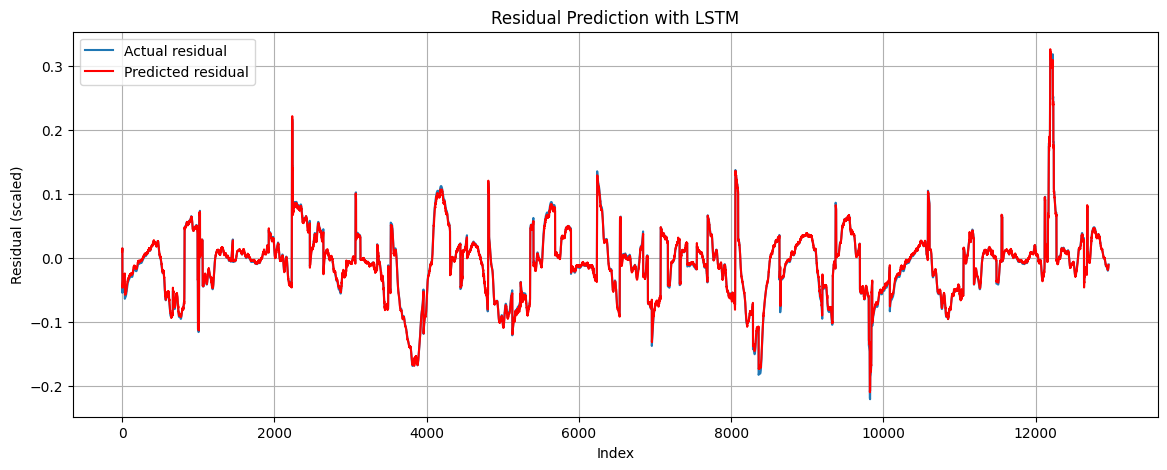

In [31]:
plt.figure(figsize=(14,5))
plt.plot(y_test_pods, label='Actual residual', color='#1f77b4')
plt.plot(pods_test_predict, label='Predicted residual', color='red')
plt.xlabel('Index')
plt.ylabel('Residual (scaled)')
plt.title('Residual Prediction with LSTM')
plt.legend()
plt.grid(True)
plt.savefig("images/pods-lstm-output.jpeg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

In [32]:
mse = mean_squared_error(y_test_pods, pods_test_predict)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_pods, pods_test_predict)
r2 = r2_score(y_test_pods, pods_test_predict)
model_two_time = (end_time - start_time) * 1000

print('=== LSTM Residual Model Metrics (scaled residuals) ===')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'MAE: {mae}')
print(f'R2: {r2}')
print(f'Prediction Time: {model_two_time}ms')

=== LSTM Residual Model Metrics (scaled residuals) ===
MSE: 2.8054318002901318e-05
RMSE: 0.0052966327041717096
MAE: 0.00236480977638672
R2: 0.9900987932224269
Prediction Time: 619.6482181549072ms


## Combine Results from Both Models

In [33]:
pods_combine_predict = np.concatenate((pods_train_predict, pods_test_predict))

final_df_pods = df_pods_residual.copy()

final_df_pods['residual_predict'] = np.nan
final_df_pods.iloc[0:len(pods_combine_predict), final_df_pods.columns.get_loc('residual_predict')] = pods_combine_predict[:, 0]
print(f"POD DATASET: Total Output: {final_df_pods.shape[0]} | Missing residual preds: {final_df_pods['residual_predict'].isna().sum()}")

final_df_pods['residual_predict'] = final_df_pods['residual_predict'].fillna(final_df_pods['residual'])

final_df_pods['y_predicted_scaled'] = final_df_pods['yhat'] + final_df_pods['residual_predict']
final_df_pods['y_true'] = target_scaler.inverse_transform(final_df_pods[['y']])
final_df_pods['y_predicted'] = target_scaler.inverse_transform(final_df_pods[['y_predicted_scaled']])

final_df_pods.head()

POD DATASET: Total Output: 43200 | Missing residual preds: 1


,ds,service_id,pod_count,request_rate_rps,latency_p95_ms,latency_p99_ms,error_rate_percent,queue_length,pod_cpu_usage_percent_avg,pod_cpu_usage_percent_p95,...,eigenvector_centrality,betweenness_centrality,closeness_centrality,y,yhat,residual,residual_predict,y_predicted_scaled,y_true,y_predicted
0,2025-11-01 00:00:00,Order,2,0.025669,0.132548,0.132659,0.002166,0.0,0.216622,0.194273,...,0.343272,0.498200,0.623649,0.0,0.094849,-0.094849,-0.086348,0.008501,2.0,2.238039
1,2025-11-01 00:01:00,Order,2,0.026770,0.160436,0.177371,0.002216,0.0,0.255984,0.232739,...,0.467365,0.603060,0.533013,0.0,0.092530,-0.092530,-0.083625,0.008905,2.0,2.249344
2,2025-11-01 00:02:00,Order,2,0.028424,0.151352,0.160443,0.002314,0.0,0.251463,0.246894,...,0.618856,0.395590,0.464586,0.0,0.090183,-0.090183,-0.082642,0.007541,2.0,2.211148
3,2025-11-01 00:03:00,Order,2,0.029590,0.131849,0.112843,0.002363,0.0,0.307713,0.288925,...,0.578566,0.545005,0.663866,0.0,0.087842,-0.087842,-0.080680,0.007162,2.0,2.200533
4,2025-11-01 00:04:00,Order,2,0.029548,0.116603,0.103859,0.002363,0.0,0.273537,0.247650,...,0.471394,0.527453,0.442977,0.0,0.085537,-0.085537,-0.078060,0.007477,2.0,2.209362


### Extract Test Dataset Related Dataframe & Calculate Metrics

In [34]:
final_df_pods_analysis = final_df_pods.iloc[train_df_pods.shape[0]:]
final_df_pods_analysis.tail()

print(f'POD DATASET: Testing Output: {final_df_pods_analysis.shape}')

POD DATASET: Testing Output: (12960, 30)


In [35]:
mse = mean_squared_error(final_df_pods_analysis['y_true'], final_df_pods_analysis['y_predicted'])
rmse = np.sqrt(mse)
mae = mean_absolute_error(final_df_pods_analysis['y_true'], final_df_pods_analysis['y_predicted'])
r2 = r2_score(final_df_pods_analysis['y_true'], final_df_pods_analysis['y_predicted'])

print('=== Hybrid Model Metrics (Pod Count) ===')
print(f'MSE: {mse:.6f}')
print(f'RMSE: {rmse:.6f}')
print(f'MAE: {mae:.6f}')
print(f'R²: {r2:.6f}')
print(f'Prediction Time: {model_one_time + model_two_time}ms')

=== Hybrid Model Metrics (Pod Count) ===
MSE: 0.007072
RMSE: 0.084095
MAE: 0.057555
R²: 0.998598
Prediction Time: 1968.432903289795ms


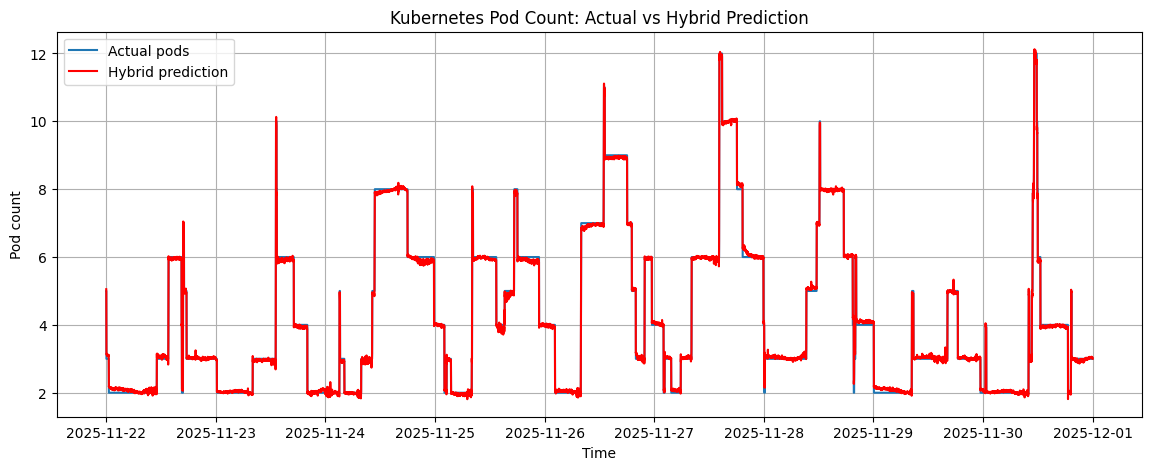

In [36]:
plt.figure(figsize=(14, 5))
plt.plot(test_df_pods['ds'], test_df_pods['pod_count'], label='Actual pods', color='#1f77b4')
plt.plot(final_df_pods_analysis['ds'], final_df_pods_analysis['y_predicted'], label='Hybrid prediction', color='red')
plt.title('Kubernetes Pod Count: Actual vs Hybrid Prediction')
plt.xlabel('Time')
plt.ylabel('Pod count')
plt.grid(True)
plt.legend()
plt.savefig("images/pods-final-output.jpeg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

## Save Models

In [37]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

filename = f'models/fbprophet-pods-{timestamp}.json'
with open(filename, 'w') as fout:
    fout.write(model_to_json(model_one))

filename = f'models/lstm-pods-{timestamp}.keras'
model_two.save(filename)